# Validation Comparison for Two CFM Models

Evaluates two trained models on the same Leiden-based validation split and reports raw W1 plus normalized W1, where `normalized_w1 = W1 / std(real)` per morphology feature.

In [1]:
from __future__ import annotations

import json
import math
import os
from dataclasses import dataclass
from pathlib import Path

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchdiffeq
from scipy.stats import wasserstein_distance

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.12.0 | CUDA available: False


## Config

Set the two checkpoint paths below. Use `architecture='pca'` for the PCA-conditioned model and `architecture='full'` for the full-expression model with an MLP gene encoder.

In [2]:
@dataclass
class EvalConfig:
    data_path: str = "data/whole_dataset_train_val.h5ad"
    output_dir: str = "outputs/validation_model_comparison"
    leiden_key: str = "leiden"
    val_fraction: float = 0.1
    seed: int = 42
    y_dim: int = 56
    time_emb_dim: int = 128
    n_eval_samples_per_cluster: int = 2048
    ode_rtol: float = 1e-5
    ode_atol: float = 1e-5
    std_eps: float = 1e-8


cfg = EvalConfig()
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
cfg.data_path = str(PROJECT_ROOT / cfg.data_path)
cfg.output_dir = str(PROJECT_ROOT / cfg.output_dir)
os.makedirs(cfg.output_dir, exist_ok=True)

MODEL_SPECS = [
    {
        "name": "pca_model",
        "architecture": "pca",
        "checkpoint_path": "models/morph/pca_model_v1.pt",
        "c_dim": 50,
        "hidden_dim": 512,
        "n_res_blocks": 6,
    },
    {
        "name": "full_input_model",
        "architecture": "film_full",
        "checkpoint_path": "models/morph/FiLM_model_v1.pt",
        "c_dim": 256,
        "gene_encoder_hidden_dim": 512,
        "hidden_dim": 512,
        "n_res_blocks": 6,
    },
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Model Definitions

In [3]:
def sinusoidal_embedding(t: torch.Tensor, dim: int) -> torch.Tensor:
    if t.dim() == 0:
        t = t.unsqueeze(0)
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000)
        * torch.arange(half, dtype=torch.float32, device=t.device)
        / max(half - 1, 1)
    )
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)


class PCAMorphologyVectorField(nn.Module):
    def __init__(self, y_dim: int, c_dim: int, hidden_dim: int, n_res_blocks: int, time_emb_dim: int) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        self.input_proj = nn.Linear(y_dim + time_emb_dim + c_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(n_res_blocks)])
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        x = self.input_proj(torch.cat([y_t, t_emb, c], dim=-1))
        for block in self.res_blocks:
            x = block(x)
        return self.output_head(x)


class FullInputMorphologyVectorField(nn.Module):
    def __init__(
        self,
        y_dim: int,
        x_dim: int,
        c_dim: int,
        gene_encoder_hidden_dim: int,
        hidden_dim: int,
        n_res_blocks: int,
        time_emb_dim: int,
    ) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.gene_encoder = nn.Sequential(
            nn.Linear(x_dim, gene_encoder_hidden_dim),
            nn.LayerNorm(gene_encoder_hidden_dim),
            nn.SiLU(),
            nn.Linear(gene_encoder_hidden_dim, c_dim),
            nn.SiLU(),
        )
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        self.input_proj = nn.Linear(y_dim + time_emb_dim + c_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(n_res_blocks)])
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, x_gene: torch.Tensor) -> torch.Tensor:
        c = self.gene_encoder(x_gene)
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        x = self.input_proj(torch.cat([y_t, t_emb, c], dim=-1))
        for block in self.res_blocks:
            x = block(x)
        return self.output_head(x)

class FiLMResBlock(nn.Module):
    def __init__(self, hidden_dim: int, cond_dim: int) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.film = nn.Linear(cond_dim, hidden_dim * 2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        gamma, beta = self.film(cond).chunk(2, dim=-1)
        h = self.linear1(torch.nn.functional.silu(self.norm1(x)))
        h = (1 + gamma) * h + beta
        h = self.linear2(torch.nn.functional.silu(self.norm2(h)))
        return x + h


class FullInputFiLMMorphologyVectorField(nn.Module):
    def __init__(
        self,
        y_dim: int,
        x_dim: int,
        c_dim: int,
        gene_encoder_hidden_dim: int,
        hidden_dim: int,
        n_res_blocks: int,
        time_emb_dim: int,
    ) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.gene_encoder = nn.Sequential(
            nn.Linear(x_dim, gene_encoder_hidden_dim),
            nn.LayerNorm(gene_encoder_hidden_dim),
            nn.SiLU(),
            nn.Linear(gene_encoder_hidden_dim, c_dim),
            nn.SiLU(),
        )
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        film_cond_dim = c_dim + time_emb_dim
        self.input_proj = nn.Linear(y_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([
            FiLMResBlock(hidden_dim, film_cond_dim) for _ in range(n_res_blocks)
        ])
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, x_gene: torch.Tensor) -> torch.Tensor:
        c = self.gene_encoder(x_gene)
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        cond = torch.cat([c, t_emb], dim=-1)
        x = self.input_proj(y_t)
        for block in self.res_blocks:
            x = block(x, cond)
        return self.output_head(self.output_norm(x))


## Data Loading and Validation Split

In [4]:
_DROP_COLUMNS = {
    "Center_X", "Center_Y",
    "BoundingBoxMinimum_X", "BoundingBoxMaximum_X",
    "BoundingBoxMinimum_Y", "BoundingBoxMaximum_Y",
    "Orientation",
    "NormalizedMoment_1_0", "NormalizedMoment_0_0", "NormalizedMoment_0_1",
}


def get_morphology_columns(obs_columns: list[str]) -> list[str]:
    cols = [c for c in obs_columns if c[0].isupper()]
    cols = [c for c in cols if c not in _DROP_COLUMNS]
    cols = [c for c in cols if not c.startswith("SpatialMoment_")]
    assert len(cols) == cfg.y_dim, f"Expected {cfg.y_dim} morphological features, got {len(cols)}"
    return cols


def split_train_val_by_leiden_clusters(leiden: np.ndarray, val_fraction: float, seed: int):
    labels, counts = np.unique(leiden.astype(str), return_counts=True)
    rng = np.random.default_rng(seed)
    tie_break = rng.permutation(len(labels))
    order = np.lexsort((tie_break, -counts))
    n = len(leiden)
    target_sizes = {"train": n * (1.0 - val_fraction), "val": n * val_fraction}
    split_sizes = {"train": 0, "val": 0}
    split_clusters = {"train": [], "val": []}
    for i in order:
        label = str(labels[i])
        count = int(counts[i])
        split = max(split_sizes, key=lambda name: target_sizes[name] - split_sizes[name])
        split_clusters[split].append(label)
        split_sizes[split] += count
    leiden_str = leiden.astype(str)
    train_idx = np.flatnonzero(np.isin(leiden_str, split_clusters["train"]))
    val_idx = np.flatnonzero(np.isin(leiden_str, split_clusters["val"]))
    return train_idx, val_idx, split_clusters


def to_dense_float32(x) -> np.ndarray:
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


print(f"Loading {cfg.data_path} ...")
adata = anndata.read_h5ad(cfg.data_path)
morph_cols = get_morphology_columns(list(adata.obs.columns))
leiden = adata.obs[cfg.leiden_key].astype(str).to_numpy()
train_idx, val_idx, split_clusters = split_train_val_by_leiden_clusters(leiden, cfg.val_fraction, cfg.seed)
print("Validation clusters:", split_clusters["val"])

y_raw = torch.tensor(adata.obs[morph_cols].values.astype(np.float32), dtype=torch.float32)
nan_mask = torch.isnan(y_raw)
if nan_mask.any():
    for j in range(y_raw.shape[1]):
        col = y_raw[:, j]
        median = col[~torch.isnan(col)].median()
        y_raw[:, j] = torch.where(torch.isnan(col), median, col)
inf_mask = torch.isinf(y_raw)
if inf_mask.any():
    for j in range(y_raw.shape[1]):
        col = y_raw[:, j]
        finite_vals = col[torch.isfinite(col)]
        median = finite_vals.median()
        y_raw[:, j] = torch.where(torch.isinf(col), median, col)

y_log = torch.sign(y_raw) * torch.log1p(torch.abs(y_raw))
y_train_log = y_log[train_idx]
y_mean = y_train_log.mean(0)
y_std = y_train_log.std(0).clamp(min=cfg.std_eps)
y_val_norm = (y_log[val_idx] - y_mean) / y_std
leiden_val = leiden[val_idx]

pca_val = torch.tensor(np.asarray(adata.obsm["X_pca"], dtype=np.float32), dtype=torch.float32)[val_idx]
full_val = torch.tensor(to_dense_float32(adata.X), dtype=torch.float32)[val_idx]
x_dim = full_val.shape[1]

print(f"Validation size: {len(val_idx):,}")
print(f"PCA input: {tuple(pca_val.shape)} | full input: {tuple(full_val.shape)} | y: {tuple(y_val_norm.shape)}")

Loading /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/data/whole_dataset_train_val.h5ad ...
Validation clusters: ['4', '11']
Validation size: 17,500
PCA input: (17500, 50) | full input: (17500, 540) | y: (17500, 56)


## Evaluation Helpers

In [5]:
def build_model(spec: dict) -> nn.Module:
    if spec["architecture"] == "pca":
        return PCAMorphologyVectorField(
            y_dim=cfg.y_dim,
            c_dim=spec["c_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    if spec["architecture"] == "full":
        return FullInputMorphologyVectorField(
            y_dim=cfg.y_dim,
            x_dim=x_dim,
            c_dim=spec["c_dim"],
            gene_encoder_hidden_dim=spec["gene_encoder_hidden_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    if spec["architecture"] == "film_full":
        return FullInputFiLMMorphologyVectorField(
            y_dim=cfg.y_dim,
            x_dim=x_dim,
            c_dim=spec["c_dim"],
            gene_encoder_hidden_dim=spec["gene_encoder_hidden_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    raise ValueError(f"Unknown architecture: {spec['architecture']}")


def validation_inputs_for(spec: dict) -> torch.Tensor:
    if spec["architecture"] == "pca":
        return pca_val
    if spec["architecture"] in {"full", "film_full"}:
        return full_val
    raise ValueError(f"Unknown architecture: {spec['architecture']}")


@torch.no_grad()
def sample_model(model: nn.Module, cond: torch.Tensor, y_real_norm: torch.Tensor):
    model.eval()
    n = len(cond)
    cond = cond.to(device)
    y0 = torch.randn(n, cfg.y_dim, device=device)

    def ode_fn(t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return model(y, t.expand(y.shape[0]), cond)

    traj = torchdiffeq.odeint(
        ode_fn,
        y0,
        torch.tensor([0.0, 1.0], device=device),
        method="dopri5",
        rtol=cfg.ode_rtol,
        atol=cfg.ode_atol,
        options={"dtype": torch.float32},
    )
    y_gen_norm = traj[-1].cpu()
    y_real_log = y_real_norm * y_std + y_mean
    y_gen_log = y_gen_norm * y_std + y_mean
    y_real = (torch.sign(y_real_log) * torch.expm1(torch.abs(y_real_log))).numpy()
    y_gen = (torch.sign(y_gen_log) * torch.expm1(torch.abs(y_gen_log))).numpy()
    return y_real, y_gen


def compute_w1_metrics(y_real: np.ndarray, y_gen: np.ndarray) -> pd.DataFrame:
    rows = []
    for i, col in enumerate(morph_cols):
        real_std = float(np.std(y_real[:, i]))
        w1 = float(wasserstein_distance(y_real[:, i], y_gen[:, i]))
        rows.append({
            "feature": col,
            "real_mean": float(np.mean(y_real[:, i])),
            "gen_mean": float(np.mean(y_gen[:, i])),
            "real_std": real_std,
            "gen_std": float(np.std(y_gen[:, i])),
            "w1": w1,
            "normalized_w1": w1 / max(real_std, cfg.std_eps),
        })
    return pd.DataFrame(rows)


def validation_sample_indices() -> np.ndarray:
    rng = np.random.default_rng(cfg.seed)
    leiden_val_str = np.asarray(leiden_val).astype(str)
    chosen = []
    for cluster in np.unique(leiden_val_str):
        cluster_idx = np.flatnonzero(leiden_val_str == cluster)
        n_cluster = min(cfg.n_eval_samples_per_cluster, len(cluster_idx))
        chosen.append(rng.choice(cluster_idx, size=n_cluster, replace=False))
    return np.concatenate(chosen)


eval_idx = validation_sample_indices()
print(f"Evaluating {len(eval_idx):,} validation cells across Leiden clusters")

Evaluating 4,096 validation cells across Leiden clusters


## Run Comparison

In [6]:
summary_rows = []
feature_tables = []

for spec in MODEL_SPECS:
    checkpoint_path = PROJECT_ROOT / spec["checkpoint_path"]
    if not checkpoint_path.exists():
        print(f"Skipping {spec['name']}: checkpoint not found at {checkpoint_path}")
        continue

    print(f"\nEvaluating {spec['name']} from {checkpoint_path}")
    model = build_model(spec).to(device)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)

    cond_val = validation_inputs_for(spec)[eval_idx]
    y_real, y_gen = sample_model(model, cond_val, y_val_norm[eval_idx])
    metrics = compute_w1_metrics(y_real, y_gen)
    metrics.insert(0, "model", spec["name"])
    feature_tables.append(metrics)
    summary_rows.append({
        "model": spec["name"],
        "architecture": spec["architecture"],
        "n_eval": int(len(eval_idx)),
        "mean_w1": float(metrics["w1"].mean()),
        "median_w1": float(metrics["w1"].median()),
        "mean_normalized_w1": float(metrics["normalized_w1"].mean()),
        "median_normalized_w1": float(metrics["normalized_w1"].median()),
    })

summary_df = (
    pd.DataFrame(summary_rows).sort_values("mean_normalized_w1")
    if summary_rows else
    pd.DataFrame(columns=["model", "architecture", "n_eval", "mean_w1", "median_w1", "mean_normalized_w1", "median_normalized_w1"])
)
feature_df = pd.concat(feature_tables, ignore_index=True) if feature_tables else pd.DataFrame()

summary_path = Path(cfg.output_dir) / "validation_model_summary.csv"
feature_path = Path(cfg.output_dir) / "validation_feature_w1.csv"
summary_df.to_csv(summary_path, index=False)
feature_df.to_csv(feature_path, index=False)

display(summary_df)
print(f"Saved {summary_path}")
print(f"Saved {feature_path}")


Evaluating pca_model from /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/models/morph/pca_model_v1.pt

Evaluating full_input_model from /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/models/morph/FiLM_model_v1.pt


,model,architecture,n_eval,mean_w1,median_w1,mean_normalized_w1,median_normalized_w1
0,pca_model,pca,4096,219.559159,0.049214,0.133879,0.137270
1,full_input_model,film_full,4096,247.789904,0.046654,0.135312,0.126862


Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/validation_model_summary.csv
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/validation_feature_w1.csv


## Plots

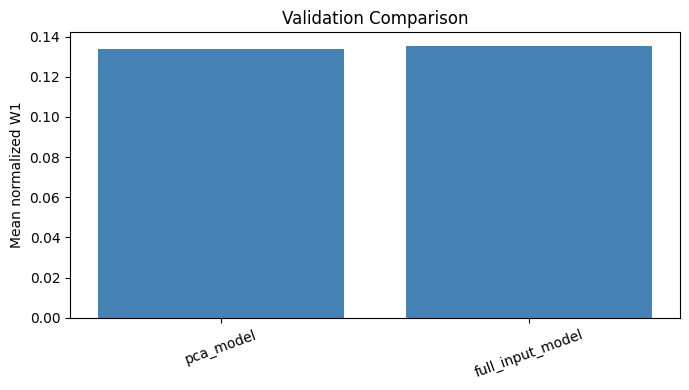

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/validation_model_summary.png


model,full_input_model,pca_model
feature,,
MedianRadius,0.276770,0.189342
HuMoment_0,0.226203,0.205627
FormFactor,0.215504,0.142321
MajorAxisLength,0.213049,0.237232
InertiaTensorEigenvalues_0,0.209009,0.238025
Compactness,0.201725,0.178716
Perimeter,0.201361,0.225127
PerimeterCrofton,0.193685,0.227678
HuMoment_1,0.189592,0.183737


In [7]:
if not summary_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(summary_df["model"], summary_df["mean_normalized_w1"], color="steelblue")
    ax.set_ylabel("Mean normalized W1")
    ax.set_title("Validation Comparison")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    path = Path(cfg.output_dir) / "validation_model_summary.png"
    plt.savefig(path, dpi=140)
    plt.show()
    print(f"Saved {path}")

if not feature_df.empty:
    pivot = feature_df.pivot(index="feature", columns="model", values="normalized_w1")
    display(pivot.sort_values(pivot.columns[0], ascending=False).head(15))